### CONEXION DDBB OLIST

In [1]:
%pip install PyMySQL
from sqlalchemy import create_engine, text
import ssl

## CONEXION BBDD MYSQL ##
DB_USER = "nuclio"
DB_PASS = "nuclioTFM6"
DB_HOST = "nuclio.mysql.database.azure.com"
DB_NAME = "olist"

# Crear engine apuntando a la base 'olist'
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}?charset=utf8mb4",
    pool_pre_ping=True,
    connect_args={"ssl": {"cert_reqs": ssl.CERT_NONE, "check_hostname": False}} 
)

# tablas 'olist'
with engine.connect() as conn:
    tables = conn.execute(text("SHOW TABLES")).fetchall()
    tables = [row[0] for row in tables]   # convertir a lista simple de strings
    
    print("Tablas en la base 'olist':")
    for t in tables:
        print("-", t)



Note: you may need to restart the kernel to use updated packages.
Tablas en la base 'olist':
- dash_olist_categorias_resumen
- dash_olist_demorados
- dash_olist_sellers
- dash_olist_states
- dash_olist_ventas_meses
- dash_sentiment_analysis
- distribucion_pedidos
- olist_customers_dataset
- olist_geolocation_dataset
- olist_order_items_dataset
- olist_order_payments_dataset
- olist_order_reviews_dataset
- olist_orders_dataset
- olist_products_dataset
- olist_sellers_dataset
- pedidos_por_tiempo
- product_category_name_translation


In [2]:
import pandas as pd
from IPython.display import display, Markdown

table = "olist_order_payments_dataset"
df = pd.read_sql_query(f"SELECT * FROM `{table}`", con=engine)

display(Markdown(f"#### Tabla: `{table}`"))
display(df.head())

# --- Mostrar valores únicos de payment_type ---
display(Markdown("#### Valores únicos de `payment_type`"))
display(df["payment_type"].unique())


#### Tabla: `olist_order_payments_dataset`

,id,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,1,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,2,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,3,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,4,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,5,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


#### Valores únicos de `payment_type`

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [5]:
import pandas as pd
from IPython.display import display, Markdown

# Cargar datos desde SQL
query = """
SELECT 
    pct.product_category_name_english AS product_category_name,
    i.price,
    i.seller_id,
    c.customer_unique_id,
    o.order_id,
    o.order_purchase_timestamp,
    r.review_score
FROM olist_order_items_dataset i
LEFT JOIN olist_products_dataset p
    ON i.product_id = p.product_id
LEFT JOIN product_category_name_translation pct
    ON p.product_category_name = pct.product_category_name
LEFT JOIN olist_orders_dataset o
    ON i.order_id = o.order_id
LEFT JOIN olist_customers_dataset c
    ON o.customer_id = c.customer_id
LEFT JOIN olist_order_reviews_dataset r
    ON o.order_id = r.order_id
WHERE o.order_status <> 'canceled'
"""
df = pd.read_sql_query(query, con=engine)

# Procesamiento temporal
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")
df["order_year"] = df["order_purchase_timestamp"].dt.year
df = df[df["order_year"].isin([2017, 2018])]

# Asegurar columnas numéricas
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Totales y KPIs
ventas_anuales = df.groupby(["product_category_name", "order_year"], dropna=False)["price"].sum().reset_index(name="total_sales")
sellers_anuales = df.groupby(["product_category_name", "order_year"], dropna=False)["seller_id"].nunique().reset_index(name="unique_sellers")
customers_anuales = df.groupby(["product_category_name", "order_year"], dropna=False)["customer_unique_id"].nunique().reset_index(name="customers")

# Clientes recurrentes
repeat_customers = (
    df.groupby(["product_category_name", "order_year", "customer_unique_id"])["order_id"]
      .nunique()
      .reset_index(name="order_count")
)
repeat_customers = (
    repeat_customers[repeat_customers["order_count"] > 1]
    .groupby(["product_category_name", "order_year"])["customer_unique_id"]
    .nunique()
    .reset_index(name="repeat_customers")
)

# Valoración media y pedidos
avg_scores = df.groupby(["product_category_name", "order_year"], dropna=False)["review_score"].mean().reset_index(name="avg_score")
orders_qty = df.groupby(["product_category_name", "order_year"], dropna=False)["order_id"].nunique().reset_index(name="orders_qty")

# Pivot generalizado
def pivot(df, value, prefix):
    return (
        df.pivot(index="product_category_name", columns="order_year", values=value)
          .fillna(0)
          .reset_index()
          .rename(columns={2017: f"{prefix}_2017", 2018: f"{prefix}_2018"})
    )

pivot_sales = pivot(ventas_anuales, "total_sales", "TotalSales")
pivot_sellers = pivot(sellers_anuales, "unique_sellers", "UniqueSellers")
pivot_customers = pivot(customers_anuales, "customers", "Customers")
pivot_repeat = pivot(repeat_customers, "repeat_customers", "RepeatCustomers")
pivot_scores = pivot(avg_scores.round(2), "avg_score", "avg_score")
pivot_orders = pivot(orders_qty, "orders_qty", "OrdersQty")

# Merge final
merged_df = (
    pivot_sales
    .merge(pivot_sellers, on="product_category_name", how="left")
    .merge(pivot_customers, on="product_category_name", how="left")
    .merge(pivot_repeat, on="product_category_name", how="left")
    .merge(pivot_scores, on="product_category_name", how="left")
    .merge(pivot_orders, on="product_category_name", how="left")
)

# Delta ventas
merged_df["delta_sales_pct_2017_2018"] = (
    (merged_df["TotalSales_2018"] - merged_df["TotalSales_2017"])
    / merged_df["TotalSales_2017"].replace(0, pd.NA)
    * 100
).round(2)

# Ordenar
merged_df = merged_df.sort_values(by="TotalSales_2018", ascending=False)

# Mostrar resultados
display(Markdown("#### Ventas, clientes, pedidos y valoración media por categoría (2017 → 2018)"))
display(
    merged_df[
        [
            "product_category_name",
            "TotalSales_2017",
            "TotalSales_2018",
            "delta_sales_pct_2017_2018",
            "OrdersQty_2017",
            "OrdersQty_2018",
            "UniqueSellers_2017",
            "UniqueSellers_2018",
            "Customers_2017",
            "Customers_2018",
            "RepeatCustomers_2017",
            "RepeatCustomers_2018",
            "avg_score_2017",
            "avg_score_2018",
        ]
    ].head(20)
)


#### Ventas, clientes, pedidos y valoración media por categoría (2017 → 2018)

order_year,product_category_name,TotalSales_2017,TotalSales_2018,delta_sales_pct_2017_2018,OrdersQty_2017,OrdersQty_2018,UniqueSellers_2017,UniqueSellers_2018,Customers_2017,Customers_2018,RepeatCustomers_2017,RepeatCustomers_2018,avg_score_2017,avg_score_2018
44,health_beauty,481142.73,770002.81,60.04,3382.0,5375.0,236.0,393.0,3297.0,5315.0,82.0,57.0,4.00,4.12
71,watches_gifts,486519.02,708305.95,45.59,2114.0,3485.0,58.0,76.0,2095.0,3442.0,18.0,38.0,3.33,4.00
8,bed_bath_table,497970.94,537514.13,7.94,4496.0,4898.0,104.0,160.0,4346.0,4808.0,139.0,89.0,3.87,3.36
66,sports_leisure,447546.59,530182.18,18.46,3621.0,4035.0,285.0,366.0,3517.0,3960.0,95.0,69.0,2.80,4.21
16,computers_accessories,400490.61,502432.09,25.45,2606.0,4030.0,176.0,206.0,2567.0,3957.0,37.0,70.0,5.00,4.75
50,housewares,227850.67,397688.06,74.54,2439.0,3399.0,228.0,364.0,2417.0,3365.0,20.0,34.0,4.29,2.92
40,furniture_decor,336272.26,385312.01,14.58,3187.0,3186.0,246.0,239.0,3113.0,3136.0,72.0,50.0,5.00,3.64
6,auto,238545.04,346632.44,45.31,1415.0,2448.0,179.0,285.0,1398.0,2426.0,17.0,22.0,5.00,0.00
7,baby,152854.33,256086.70,67.54,1203.0,1656.0,110.0,193.0,1192.0,1643.0,11.0,12.0,3.80,3.00
21,cool_stuff,388971.98,230752.41,-40.68,2200.0,1409.0,183.0,164.0,2195.0,1401.0,5.0,8.0,2.40,5.00


In [8]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# Traer los datos desde SQL con los pagos agrupados
query = """
WITH pay_agg AS (
    SELECT
        order_id,
        MAX(payment_type) AS payment_type,
        AVG(payment_installments) AS avg_installments
    FROM olist_order_payments_dataset
    GROUP BY order_id
)
SELECT 
    pct.product_category_name_english AS product_category_name,
    i.price,
    o.order_id,
    o.order_purchase_timestamp,
    pay.payment_type,
    pay.avg_installments
FROM olist_order_items_dataset i
LEFT JOIN olist_products_dataset p ON i.product_id = p.product_id
LEFT JOIN product_category_name_translation pct ON p.product_category_name = pct.product_category_name
LEFT JOIN olist_orders_dataset o ON i.order_id = o.order_id
LEFT JOIN pay_agg pay ON i.order_id = pay.order_id
WHERE o.order_status <> 'canceled'
"""
df = pd.read_sql_query(query, con=engine)

# Limpiar datos y quedarnos con los años 2017 y 2018
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")
df["order_year"] = df["order_purchase_timestamp"].dt.year
df = df[df["order_year"].isin([2017, 2018])]
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["avg_installments"] = pd.to_numeric(df["avg_installments"], errors="coerce")

# Calcular ventas por categoría y año
ventas_anuales = df.groupby(["product_category_name", "order_year"], dropna=False)["price"].sum().reset_index()
pivot_sales = ventas_anuales.pivot(index="product_category_name", columns="order_year", values="price").fillna(0).reset_index()
pivot_sales.rename(columns={2017: "TotalSales_2017", 2018: "TotalSales_2018"}, inplace=True)

# Calcular cantidad de pedidos por categoría y año
pedidos = df.groupby(["product_category_name", "order_year"], dropna=False)["order_id"].nunique().reset_index()
pivot_orders = pedidos.pivot(index="product_category_name", columns="order_year", values="order_id").fillna(0).reset_index()
pivot_orders.rename(columns={2017: "OrdersQty_2017", 2018: "OrdersQty_2018"}, inplace=True)

# Calcular ticket medio (ventas / pedidos)
avg_ticket = pivot_sales.merge(pivot_orders, on="product_category_name", how="left")
for year in [2017, 2018]:
    ventas = avg_ticket[f"TotalSales_{year}"].astype(float)
    pedidos = avg_ticket[f"OrdersQty_{year}"].replace(0, np.nan).astype(float)
    avg_ticket[f"AvgTicket_{year}"] = (ventas / pedidos).round(2)
avg_ticket = avg_ticket[["product_category_name", "AvgTicket_2017", "AvgTicket_2018"]]

# Calcular promedio de cuotas por categoría y año
avg_installments = df.groupby(["product_category_name", "order_year"], dropna=False)["avg_installments"].mean().reset_index()
pivot_installments = avg_installments.pivot(index="product_category_name", columns="order_year", values="avg_installments").fillna(0).round(2).reset_index()
pivot_installments.rename(columns={2017: "AvgInstallments_2017", 2018: "AvgInstallments_2018"}, inplace=True)

# Calcular ventas por tipo de pago
ventas_tipo = df.groupby(["product_category_name", "order_year", "payment_type"], dropna=False)["price"].sum().reset_index()
total_tipo = df.groupby(["product_category_name", "order_year"], dropna=False)["price"].sum().reset_index()
total_tipo.rename(columns={"price": "total_sales_total"}, inplace=True)

# Calcular porcentaje de ventas por método de pago
merged = ventas_tipo.merge(total_tipo, on=["product_category_name", "order_year"], how="left")
merged["pct_sales_payment_type"] = ((merged["price"] / merged["total_sales_total"].replace(0, np.nan)) * 100).round(2)

# Pivot para mostrar los métodos de pago como columnas
pivot_payment = merged.pivot_table(index=["product_category_name", "order_year"], columns="payment_type", values="pct_sales_payment_type", fill_value=0).reset_index()

# Pivot final por años
pivot_final = pivot_payment.pivot(index="product_category_name", columns="order_year")
pivot_final.columns = [f"{col2}_{col1}" for col1, col2 in pivot_final.columns]
pivot_final = pivot_final.reset_index().fillna(0)

# Unir todo en un único dataframe
merged_df = (
    pivot_sales
    .merge(pivot_orders, on="product_category_name", how="left")
    .merge(avg_ticket, on="product_category_name", how="left")
    .merge(pivot_installments, on="product_category_name", how="left")
    .merge(pivot_final, on="product_category_name", how="left")
)

# Ordenar por ventas 2018
merged_df = merged_df.sort_values(by="TotalSales_2018", ascending=False)

# Mostrar resultados
display(Markdown("#### Ventas totales, pedidos, ticket medio, cuotas promedio y % por método de pago (2017–2018)"))
display(
    merged_df[
        [
            "product_category_name",
            "TotalSales_2017", "TotalSales_2018",
            "OrdersQty_2017", "OrdersQty_2018",
            "AvgTicket_2017", "AvgTicket_2018",
            "AvgInstallments_2017", "AvgInstallments_2018"
        ] + [
            col for col in merged_df.columns 
            if any(x in col for x in ["credit_card", "boleto", "debit_card", "voucher", "not_defined"])
        ]
    ].head(20)
)


#### Ventas totales, pedidos, ticket medio, cuotas promedio y % por método de pago (2017–2018)

,product_category_name,TotalSales_2017,TotalSales_2018,OrdersQty_2017,OrdersQty_2018,AvgTicket_2017,AvgTicket_2018,AvgInstallments_2017,AvgInstallments_2018,2017_boleto,2018_boleto,2017_credit_card,2018_credit_card,2017_debit_card,2018_debit_card,2017_voucher,2018_voucher
44,health_beauty,481142.73,770002.81,3382.0,5375.0,142.27,143.26,3.21,2.98,18.08,15.75,78.98,80.20,0.27,2.10,2.67,1.96
71,watches_gifts,486519.02,708305.95,2114.0,3485.0,230.14,203.24,3.74,3.71,14.07,11.12,82.45,83.39,0.15,2.28,3.32,3.21
8,bed_bath_table,497970.94,537514.13,4496.0,4898.0,110.76,109.74,3.91,3.50,15.06,15.31,80.86,78.94,0.49,2.15,3.59,3.60
66,sports_leisure,447546.59,530182.18,3621.0,4035.0,123.60,131.40,2.71,2.38,19.08,16.46,76.52,78.91,0.96,2.24,3.44,2.39
16,computers_accessories,400490.61,502432.09,2606.0,4030.0,153.68,124.67,2.61,2.06,31.05,26.66,65.01,69.21,0.78,1.96,3.16,2.17
50,housewares,227850.67,397688.06,2439.0,3399.0,93.42,117.00,3.04,3.07,17.57,16.99,77.21,76.25,1.05,2.61,4.17,4.15
40,furniture_decor,336272.26,385312.01,3187.0,3186.0,105.51,120.94,3.35,3.03,19.92,19.54,76.08,75.71,0.68,1.15,3.32,3.60
6,auto,238545.04,346632.44,1415.0,2448.0,168.58,141.60,3.30,2.67,18.30,14.86,78.16,79.67,0.75,1.38,2.79,4.10
7,baby,152854.33,256086.70,1203.0,1656.0,127.06,154.64,3.05,2.87,18.32,13.24,78.31,82.91,0.60,1.30,2.77,2.55
21,cool_stuff,388971.98,230752.41,2200.0,1409.0,176.81,163.77,3.40,3.25,18.58,15.19,77.80,80.16,0.38,1.51,3.23,3.14


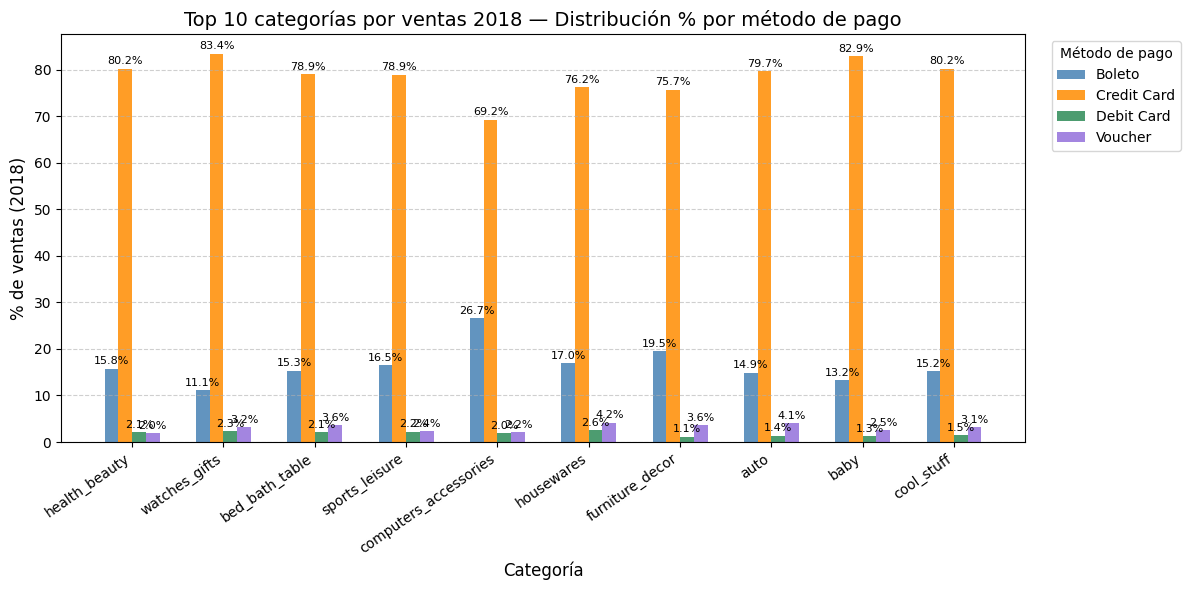

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Seleccionar las 10 categorías con más ventas en 2018
top10 = merged_df.sort_values(by="TotalSales_2018", ascending=False).head(10)

# Buscar las columnas que tienen datos de métodos de pago del año 2018
payment_cols_2018 = [col for col in top10.columns if col.startswith("2018_")]
payment_types = [col.split("_", 1)[1] for col in payment_cols_2018]

# Preparar los datos para el gráfico
categories = top10["product_category_name"].tolist()
values = {ptype: top10[f"2018_{ptype}"].values for ptype in payment_types}

# Crear la figura
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(categories))
width = 0.15
offsets = np.linspace(-width * (len(payment_types)-1)/2, width * (len(payment_types)-1)/2, len(payment_types))

# Definir los colores para cada tipo de pago
colors = ["steelblue", "darkorange", "seagreen", "mediumpurple", "lightgray"]

# Dibujar las barras y las etiquetas con los porcentajes
for i, ptype in enumerate(payment_types):
    bars = ax.bar(
        x + offsets[i],
        values[ptype],
        width,
        label=ptype.replace("_", " ").title(),
        color=colors[i % len(colors)],
        alpha=0.85
    )
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.5,
                f"{height:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8
            )

# Personalizar el gráfico
ax.set_title("Top 10 categorías por ventas 2018 — Distribución % por método de pago", fontsize=14)
ax.set_xlabel("Categoría", fontsize=12)
ax.set_ylabel("% de ventas (2018)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=35, ha="right")
ax.legend(title="Método de pago", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


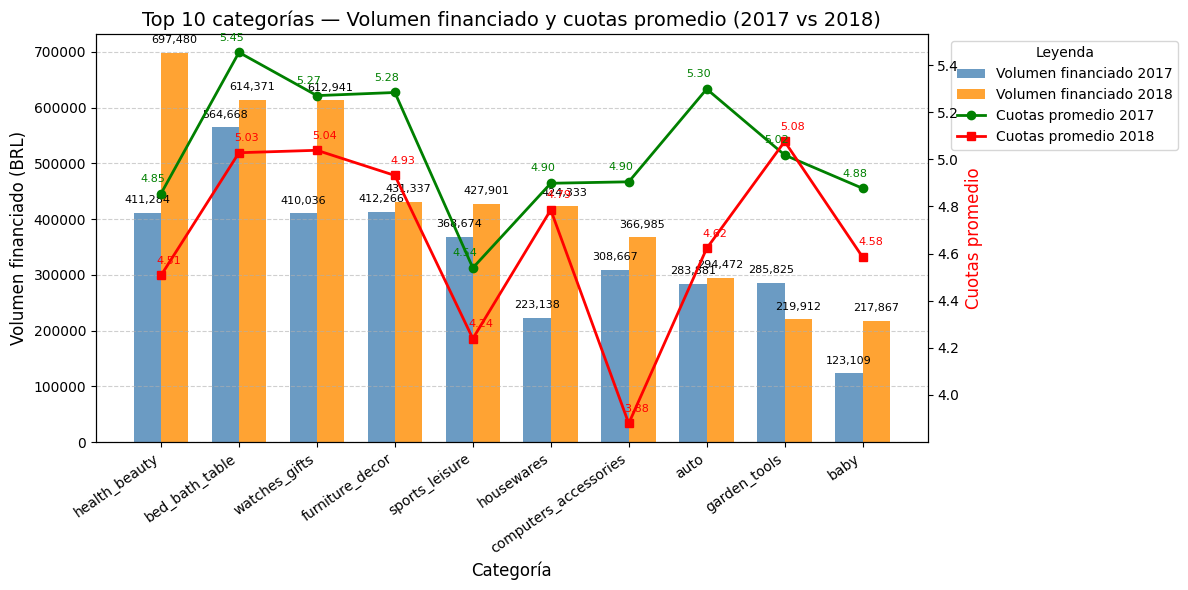

#### Top 10 categorías — Volumen financiado y cuotas promedio (2017 vs 2018)

,product_category_name,total_financed_sales_2017,total_financed_sales_2018,avg_installments_2017,avg_installments_2018
44,health_beauty,411284.47,697480.05,4.854176,4.506963
8,bed_bath_table,564667.78,614371.33,5.453620,5.027748
70,watches_gifts,410035.53,612941.23,5.270142,5.038141
40,furniture_decor,412265.73,431336.59,5.283413,4.931308
65,sports_leisure,368673.64,427900.67,4.538964,4.238929
50,housewares,223138.31,424333.36,4.898172,4.785262
16,computers_accessories,308666.56,366984.64,4.904321,3.878805
6,auto,283880.66,294472.12,5.298144,4.621821
43,garden_tools,285824.65,219911.50,5.018139,5.075452
7,baby,123108.81,217866.73,4.876652,4.584865


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown

# Cargar datos con pagos incluidos
query = """
SELECT 
    pct.product_category_name_english AS product_category_name,
    i.price,
    o.order_id,
    o.order_purchase_timestamp,
    pay.payment_type,
    pay.payment_installments,
    pay.payment_value
FROM olist_order_items_dataset i
LEFT JOIN olist_products_dataset p
    ON i.product_id = p.product_id
LEFT JOIN product_category_name_translation pct
    ON p.product_category_name = pct.product_category_name
LEFT JOIN olist_orders_dataset o
    ON i.order_id = o.order_id
LEFT JOIN olist_order_payments_dataset pay
    ON i.order_id = pay.order_id
WHERE o.order_status <> 'canceled'
"""
df = pd.read_sql_query(query, con=engine)

# Asegurar formato de fechas y años
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")
df["order_year"] = df["order_purchase_timestamp"].dt.year
df = df[df["order_year"].isin([2017, 2018])]

# Filtrar solo las compras que tienen más de una cuota
df_cuotas = df[df["payment_installments"] > 1].copy()

# Calcular el volumen total financiado y la media de cuotas por categoría y año
ventas_cuotas = (
    df_cuotas.groupby(["product_category_name", "order_year"], dropna=False)
    .agg(
        total_financed_sales=("payment_value", "sum"),
        avg_installments=("payment_installments", "mean")
    )
    .reset_index()
)

# Reorganizar columnas para tener 2017 y 2018 separados
pivot = ventas_cuotas.pivot(index="product_category_name", columns="order_year")
pivot.columns = [f"{col1}_{col2}" for col1, col2 in pivot.columns]
pivot = pivot.reset_index().fillna(0)

# Detectar nombres de columnas automáticamente
col_sales_2017 = [c for c in pivot.columns if "2017" in c and "total_financed_sales" in c][0]
col_sales_2018 = [c for c in pivot.columns if "2018" in c and "total_financed_sales" in c][0]
col_inst_2017 = [c for c in pivot.columns if "2017" in c and "avg_installments" in c][0]
col_inst_2018 = [c for c in pivot.columns if "2018" in c and "avg_installments" in c][0]

# Tomar las 10 categorías con más volumen financiado en 2018
pivot = pivot.sort_values(by=col_sales_2018, ascending=False).head(10)

# Preparar datos para graficar
categories = pivot["product_category_name"].tolist()
sales_2017 = pivot[col_sales_2017].values
sales_2018 = pivot[col_sales_2018].values
installments_2017 = pivot[col_inst_2017].values
installments_2018 = pivot[col_inst_2018].values

x = np.arange(len(categories))
width = 0.35

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras de volumen financiado
bars1 = ax1.bar(x - width/2, sales_2017, width, label="Volumen financiado 2017", color="steelblue", alpha=0.8)
bars2 = ax1.bar(x + width/2, sales_2018, width, label="Volumen financiado 2018", color="darkorange", alpha=0.8)

# Etiquetas de valores
max_height = max(sales_2017.max(), sales_2018.max())
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(
                bar.get_x() + bar.get_width()/2,
                height + (0.02 * max_height),
                f"{height:,.0f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

# Eje secundario con cuotas promedio
ax2 = ax1.twinx()
ax2.plot(x, installments_2017, color="green", marker="o", linewidth=2, label="Cuotas promedio 2017")
ax2.plot(x, installments_2018, color="red", marker="s", linewidth=2, label="Cuotas promedio 2018")

# Etiquetas sobre las líneas
for i, (val17, val18) in enumerate(zip(installments_2017, installments_2018)):
    if val17 > 0:
        ax2.text(x[i] - 0.1, val17 + 0.05, f"{val17:.2f}", color="green", fontsize=8, ha="center")
    if val18 > 0:
        ax2.text(x[i] + 0.1, val18 + 0.05, f"{val18:.2f}", color="red", fontsize=8, ha="center")

# Personalizar gráfico
ax1.set_title("Top 10 categorías — Volumen financiado y cuotas promedio (2017 vs 2018)", fontsize=14)
ax1.set_xlabel("Categoría", fontsize=12)
ax1.set_ylabel("Volumen financiado (BRL)", fontsize=12)
ax2.set_ylabel("Cuotas promedio", fontsize=12, color="red")
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=35, ha="right")

# Combinar leyendas
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, bbox_to_anchor=(1.02, 1), loc="upper left", title="Leyenda")

ax1.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Mostrar resumen
display(Markdown("#### Top 10 categorías — Volumen financiado y cuotas promedio (2017 vs 2018)"))
display(pivot[[ "product_category_name", col_sales_2017, col_sales_2018, col_inst_2017, col_inst_2018 ]])


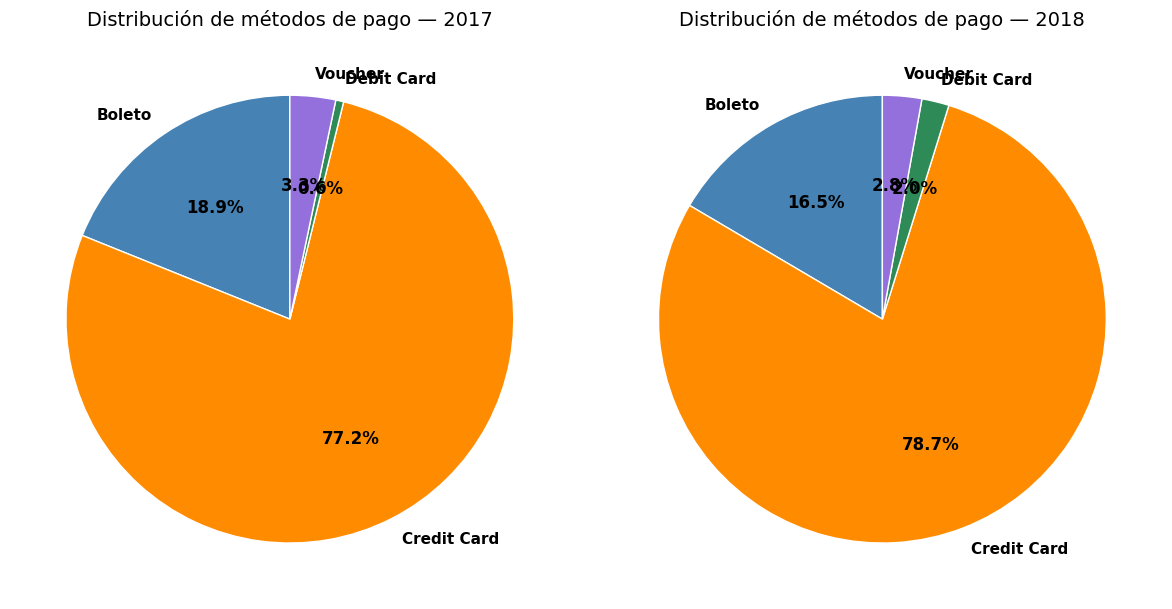

In [12]:
import matplotlib.pyplot as plt

# Detectar las columnas que contienen los porcentajes de métodos de pago por año
payment_cols_2017 = [col for col in merged_df.columns if col.startswith("2017_")]
payment_cols_2018 = [col for col in merged_df.columns if col.startswith("2018_")]

# Calcular la distribución global de cada método de pago ponderada por ventas
def aggregate_payment_distribution(df, cols, year):
    payments = {}
    for col in cols:
        payment_type = col.split("_", 1)[1]
        payments[payment_type] = (df[col] * df[f"TotalSales_{year}"] / 100).sum()
    total = sum(payments.values())
    return {k: round(v / total * 100, 2) for k, v in payments.items() if total > 0}

dist_2017 = aggregate_payment_distribution(merged_df, payment_cols_2017, 2017)
dist_2018 = aggregate_payment_distribution(merged_df, payment_cols_2018, 2018)

# Definir colores para los gráficos
colors = ["steelblue", "darkorange", "seagreen", "mediumpurple", "lightgray"]

# Crear la figura con dos gráficos de tarta
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Función para dibujar cada gráfico
def make_pie(ax, data, title):
    wedges, texts, autotexts = ax.pie(
        data.values(),
        labels=[k.replace("_", " ").title() for k in data.keys()],
        colors=colors[:len(data)],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={'edgecolor': 'white'},
        textprops={'fontsize': 10, 'color': 'black', 'weight': 'bold'}
    )
    ax.set_title(title, fontsize=14, pad=10)
    for t in texts:
        t.set_fontsize(11)
        t.set_color("black")
    for a in autotexts:
        a.set_fontsize(12)
        a.set_color("black")
        a.set_weight("bold")

# Dibujar los dos gráficos
make_pie(axes[0], dist_2017, "Distribución de métodos de pago — 2017")
make_pie(axes[1], dist_2018, "Distribución de métodos de pago — 2018")

plt.tight_layout()
plt.show()
